In [125]:
import pandas as pd
import numpy as np
import modelseedpy 
import json
import re
import re
import cobra
from cobra.io import load_json_model, save_json_model
from cobra import Model, Reaction, Metabolite
from bioservices import KEGG
import re
from scipy.stats import ranksums
import statsmodels.stats.multitest as multi
import math
from copy import deepcopy
import scipy
import seaborn as sns

import working_w_seed_models as mm
from importlib import reload
from cobra.flux_analysis import flux_variability_analysis
import configparser
import pickle
import argparse



# manual metabolomic to model seed conversions
d2 = {'2-hydroxybutyrate/2-hydroxyisobutyrate':'cpd03561',
      '4-hydroxyphenylacetate sulfate\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0':'cpd00489',
      '5-methylthioribose**':'cpd01981',
      'bilirubin (Z,Z)':'cpd00376',
      'cis-urocanate':'cpd00581',
      'riboflavin (Vitamin B2)': 'cpd00220',
      'tauroursodeoxycholate': 'cpd17168',
      'pipecolate': 'cpd00323',
      'sphingadienine': 'cpd25264',
      'palmitoylcarnitine': 'cpd01915',
      'oleoylcarnitine (C18:1)': 'cpd33454',
      'nicotinate ribonucleoside': 'cpd03471',
      'N-formylmethionine': 'cpd02012',
      "N('1)-acetylspermidine": 'cpd00470',
      'methylmalonate (MMA)':'cpd01468',
      'gamma-aminobutyrate (GABA)':'cpd11408',
       'hexadecasphingosine (d16:1)*':'',
       'laurate (12:0)':'cpd01741',
      'N-acetylglutamine': 'cpd01760',
      'N-acetyl-beta-glucosaminylamine': 'cpd00912',
     'N-acetylasparagine':'cpd25519', 
     'N-acetylaspartate (NAA)':'cpd00767',
     'N-acetylcitrulline': 'cpd11209',
     'N-acetylglucosaminylasparagine': 'cpd02763',
     'N-acetylglutamate': 'cpd00477',
     'N-acetylhistidine': 'cpd24478',
     'N-acetyltryptophan': 'cpd27567',
     'threonine': 'cpd00161',
     'proline': 'cpd00129',
     'N1-methylguanosine':'cpd25947',
     'N1-methyladenosine': 'cpd01637',
     'histidine betaine (hercynine)*': 'cpd03305',
     'glycerophosphoserine*': 'cpd15468',
     'cysteine': 'cpd00084'

     }


# Read in metabolomics data
def getData(fname_metabolomics):
    df = pd.read_excel(fname_metabolomics, sheet_name="GF.5 MetabolomicsDataset", skiprows = np.arange(7), index_col = "BIOCHEMICAL")

    feature_info = ["PATHWAY_SORTORDER", "SUPER_PATHWAY", "SUB_PATHWAY", "COMP_ID", "PLATFORM", "CHEMICAL_ID", "RI", "MASS", "CAS", "PUBCHEM", "CHEMSPIDER", "KEGG","                               Group   HMDB_ID"]
    feature_annotation = df.loc[:, feature_info]
    df = df.drop(feature_info, axis = 1)

    # Drop rows (metabolites) with too many NAs
    print("Starting with ", df.shape[0], " features")
    keep = df.isna().sum(axis = 1) / df.shape[1] < 0.5
    print("Keeping ", sum(keep), " after removing those with > 25% NA")
    df = df.loc[keep, :]

    # Drop columns (samples) with too many NAs
    print("Starting with ", df.shape[1], " samples")
    keep = df.isna().sum(axis = 0) / df.shape[0] < 0.25
    print("Keeping ", sum(keep), " after removing those with > 25% NA")
    df = df.loc[:, keep]
    
    
    df_norm = df.div(df.median(axis=1), axis=0)
    df_norm = df_norm.transform('log')
    df_norm = df_norm.loc[["X -" not in i for i in df_norm.index.values], :]
    
    df = df.transform('log')
    df = df.loc[["X -" not in i for i in df.index.values], :]
    
    print(df.shape)
    return(df.T, df_norm.T)

# read in metadata

def getMetadata(df):
    metadata = pd.DataFrame(index = df.index.values)
    metadata['condition'] = [str(i).split(" ")[0] for i in df.index.values]
    metadata['condition'] = [str(i).split(".")[0] for i in metadata['condition'].values]
    metadata['condition'][metadata['condition'] == "Germ"] = "GF"
    metadata.condition.unique()
    return(metadata)

def findDifferentialMetabolites(df_norm, condition1, condition2, alternative):

	gf = df_norm.loc[df_norm.index.values == condition1, ]
	pbi = df_norm.loc[df_norm.index.values == condition2, ]
	# calc. metabolites with a significant increase in pbi

	pvals = []
	for met in pbi.columns.values:
	    tmp = scipy.stats.ranksums(gf.loc[:, met].values, pbi.loc[:, met].values, alternative = alternative)
	    pvals.append(tmp[1])
	pvals = np.array(pvals)
	pvals[[math.isnan(i) for i in pvals]] = 1

	p_adj = multi.multipletests(pvals, method = "fdr_by")[1]
	sns.histplot(p_adj, bins = 100)
	mets = pbi.columns.values[p_adj <= .05]

	return(mets)

def metaboliteIsReachable(model, met):
    # finds all reactions that produce the metabolite
    # removes any direct transport reactions that produce the metabolite
    # checks if metabolite is still reachable
    
    producing_reactions = model.find_producing_reactions(met)
    direct_transport = [i for i in producing_reactions if i.id in model.getTransportReactions()]
    if len(direct_transport) > 0:
        reaction_save = direct_transport
        model.model.remove_reactions(direct_transport)
    producing_reactions = model.find_producing_reactions(met)
    transport_reactions = model.getTransportReactions()
    model.enableTransportReactions()
    reachable_reaction_ids, not_reachable_reactions, reachable_metabolite_ids, not_reachable_metabolites = model.findUnreachables(transport_reactions)
    return(met in reachable_metabolite_ids)


def calculateReachableReactions(model):
	# calc reachable
	num_reachable_metabolites = []
	num_reachable_reactions = []
	reachable_metabolites = {}
	previously_reachable_metabolites = -1
	i = 0
	while len(model.reachable_metabolite_ids) != previously_reachable_metabolites:
	    previously_reachable_metabolites = len(model.reachable_metabolite_ids)
	    transport_reactions = model.getTransportReactions()
	    model.enableTransportReactions()
	    reachable_reaction_ids, not_reachable_reactions, reachable_metabolite_ids, not_reachable_metabolites = model.findUnreachables(transport_reactions)
	    model.reachable_metabolite_ids = reachable_metabolite_ids
	    model.reachable_reaction_ids = reachable_reaction_ids
	    model.reachable_metabolite_ids
	    num_reachable_metabolites.append(len(model.reachable_metabolite_ids))
	    num_reachable_reactions.append(len(model.reachable_reaction_ids))
	    reachable_metabolites[i] = model.reachable_metabolite_ids
	    print(i, len(model.reachable_metabolite_ids))
	    i = i + 1
	return(model)

def convertMetabolomicsToModelSeed(mets, fname_compound_lookup):
    compound_df = pd.read_csv(fname_compound_lookup, sep = "\t")
    keep = [i == i for i in compound_df['aliases']]
    compound_df = compound_df.loc[keep, :]

    d = {}
    #d2 = {}
    for met in mets:
        for i in range(compound_df.shape[0]):
            aliases = compound_df.aliases.values[i].split(";")
            aliases = [i.replace("Name: ", "").strip().lower() for i in aliases]
            if met in aliases:
	            d[met] = compound_df.id.values[i]
	            #d2[met] = aliases
    d['asparagine'] = 'cpd00132'
    d['fructose'] = 'cpd00082'
    d['ribose'] = 'cpd00105'


    return(d)



build_pbi_model.ini


/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:42: DtypeWarning: Columns (1,3,4,6,7,8,9,11,12,13,16,17,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  self.db = pd.read_csv(database_path)
/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1369: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  db_compound = pd.read_csv(compounds_filepath, sep = "\t", index_col = 0)


Length of conversions after 1st method:  721


/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1390: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  compounds = pd.read_csv(compounds_filepath, sep = "\t").set_index("name")


Length of conversions after 2nd method:  806
Length of conversions after 3rd method:  891
Starting with  945  features
Keeping  859  after removing those with > 25% NA
Starting with  48  samples
Keeping  48  after removing those with > 25% NA
(708, 48)


...

Number metabolites increased in vitro but missing modelseed ID:  37
Number of metabolites increased in vitro and have modelseed ID:  67
Missing ids: 
Metabolites that are produced in metabolomics and already in the model:  ['4MOP [c0]', '5-Aminopentanoate [c0]', '5-Methylthio-D-ribose [c0]', 'Agmatine [c0]', '2-Oxoglutarate [c0]', 'Urocanate [c0]', 'Cytosine [c0]', 'Dihydrobiopterin [c0]', 'Glycerophosphoglycerol [c0]', 'HYXN [c0]', 'ddca [c0]', 'L-Methionine [c0]', 'N-Acetyl-L-citrulline [c0]', 'N-Acetyl-L-glutamate [c0]', 'N-Ribosylnicotinamide [c0]', 'Niacin [c0]', 'Nicotinate D-ribonucleoside [c0]', 'Orotate [c0]', 'PAN [c0]', 'Phenylpyruvate [c0]', 'Pyridoxal [c0]', 'Riboflavin [c0]', 'Succinate [c0]', 'Taurine [c0]', 'Thymine [c0]', 'Urocanate [c0]', 'Tyramine [c0]', 'Uracil [c0]']
0 271
1 339
2 372
3 401
4 424
5 439
6 466
7 485
8 506
9 527
10 543
11 555
12 568
13 577
14 582
15 585
16 590
17 594
18 598
19 601
20 603
21 605
22 607
23 607
Metabolites already reachable:           me

/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:42: DtypeWarning: Columns (1,3,4,6,7,8,9,11,12,13,16,17,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  self.db = pd.read_csv(database_path)
/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1369: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  db_compound = pd.read_csv(compounds_filepath, sep = "\t", index_col = 0)


Length of conversions after 1st method:  721


/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1390: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  compounds = pd.read_csv(compounds_filepath, sep = "\t").set_index("name")


Length of conversions after 2nd method:  806
Length of conversions after 3rd method:  891


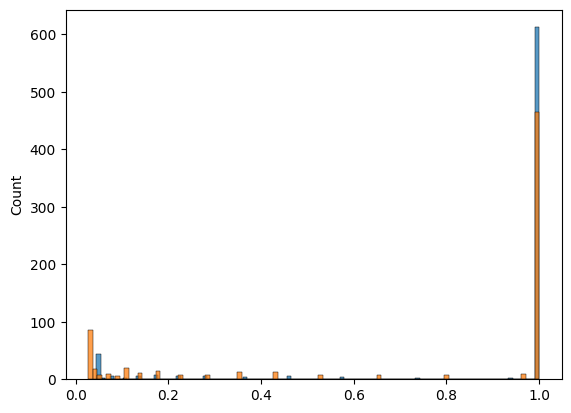

In [4]:
params_file = "build_pbi_model.ini"
#parser = argparse.ArgumentParser(prog='bifermentans_model_adding_metabolomics.py')
#parser.add_argument("--params_file", type = str)
#args = parser.parse_args()

# 0. Read in config file
config = configparser.ConfigParser()
config.read(params_file)
project_dir = config.get('paths', 'project_dir')

# 1. Read in data
params_file = params_file
config = configparser.ConfigParser()
print(params_file)
config.read(params_file)
model_cobra = cobra.io.load_json_model(project_dir + config.get('paths', 'output_dir') + "bifermentans_gapfilled_from_cdiff.json")
model = mm.Model(model_cobra, config)
model.model.optimize().objective_value

df, df_norm = getData(project_dir + config.get('paths', 'fname_metabolomics'))
metadata = getMetadata(df)
df.index = metadata.loc[df.index.values, "condition"]
df_norm.index = metadata.loc[df_norm.index.values, "condition"]

mets_used = findDifferentialMetabolites(df_norm, "GF", "PBI", "greater")
mets_produced = findDifferentialMetabolites(df_norm, "GF", "PBI", "less")


plot = False
if plot:
    df_norm = pd.concat([df_norm.loc[df_norm.index.values == condition1, ], df_norm.loc[df_norm.index.values == condition2, ]]).loc[:, mets_produced]
    df_norm['condition'] = df_norm.index.values
    df_melt = df_norm.melt('condition')
    df_melt['BIOCHEMICAL'] = [i.replace("BIOCHEMICAL=", "") for i in df_melt.BIOCHEMICAL.values]

    #sns.boxplot(df, facet_kws=dict(margin_titles=True))
    g = sns.FacetGrid(df_melt, col="BIOCHEMICAL", sharey= False, col_wrap = 5)
    g.map(sns.boxplot, "condition", "value")
    g.set_titles("{col_name}");
    plt.savefig("differential_metabolites.png")


d = convertMetabolomicsToModelSeed(mets_produced, project_dir + config.get('paths', 'modelseed_compound_db'))
met_id_dict = {**d, **d2}

print("Number metabolites increased in vitro but missing modelseed ID: ", len([i for i in mets_produced if i not in met_id_dict]))
print("Number of metabolites increased in vitro and have modelseed ID: ", len([i for i in mets_produced if i in met_id_dict]))
print("Missing ids: ")
[i for i in mets_produced if i not in met_id_dict]

# 1. For compounds already in the model, add reactions from c. diff model to make them reachable
## A. Identify compounds that are already in the model=
need_to_reach = [met_id_dict[i] + "_c0" for i in mets_produced if i in met_id_dict]
need_to_reach = np.array(need_to_reach)[[i in model.metabolite_id_list for i in need_to_reach]]
print("Metabolites that are produced in metabolomics and already in the model: ", [model.model.metabolites.get_by_id(i).name for i in need_to_reach])

## B. Identify which of those compounds are already reachable
model = calculateReachableReactions(model)

accessible = [(i, model.model.metabolites.get_by_id(i).name) for i in need_to_reach if metaboliteIsReachable(model, i)]
accessible = pd.DataFrame(accessible, columns=["met_id", "name"])
print("Metabolites already reachable: ", accessible)

missing = [(i, model.model.metabolites.get_by_id(i).name) for i in need_to_reach if not metaboliteIsReachable(model, i)]
missing = pd.DataFrame(missing, columns=["met_id", "name"])
print("Metabolites that need more reactions: ", missing)



In [27]:
## C. For the metabolites that need more reactions, port from C. diff model where possible
model_cobra = cobra.io.load_json_model(project_dir + config.get('paths', 'model_cdiff'))
cdiff_model = mm.Model(model_cobra, config)
conversions2 = {}
i = 0
print(len(cdiff_model.conversions))
for key, value in cdiff_model.conversions.items():
    conversions2[value] = key
    i += 1
    print(i, end = "\t")



/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:42: DtypeWarning: Columns (1,3,4,6,7,8,9,11,12,13,16,17,19,20,21,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  self.db = pd.read_csv(database_path)
/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1369: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  db_compound = pd.read_csv(compounds_filepath, sep = "\t", index_col = 0)


Length of conversions after 1st method:  721


/home/christine/Partners HealthCare Dropbox/Christine Tataru/metabolic_modeling/scripts/metabolic_models/working_w_seed_models.py:1390: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  compounds = pd.read_csv(compounds_filepath, sep = "\t").set_index("name")


Length of conversions after 2nd method:  806
Length of conversions after 3rd method:  891
867
1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23	24	25	26	27	28	29	30	31	32	33	34	35	36	37	38	39	40	41	42	43	44	45	46	47	48	49	50	51	52	53	54	55	56	57	58	59	60	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	100	101	102	103	104	105	106	107	108	109	110	111	112	113	114	115	116	117	118	119	120	121	122	123	124	125	126	127	128	129	130	131	132	133	134	135	136	137	138	139	140	141	142	143	144	145	146	147	148	149	150	151	152	153	154	155	156	157	158	159	160	161	162	163	164	165	166	167	168	169	170	171	172	173	174	175	176	177	178	179	180	181	182	183	184	185	186	187	188	189	190	191	192	193	194	195	196	197	198	199	200	201	202	203	204	205	206	207	208	209	210	211	212	213	214	215	216	217	218	219	220	221	222	223	224	225	226	227	228	229	230	231	232	233	234	235	236	237	238	239	240	241	242	243	244	245	246	247	248	249	250	251	252	253	25

In [ ]:
conversions2 = {value: key for key, value in cdiff_model.conversions.items()}
for met_id in missing.met_id.values:
    if met_id in conversions2:
        print(met_id)
        producing_reactions = cdiff_model.find_producing_reactions(conversions2[met_id])
        producing_reactions = [i for i in producing_reactions if i.id not in cdiff_model.getTransportReactions()]
        print(producing_reactions)
        model.addCdiffReaction(cdiff_model, producing_reactions[0].id, enable_exchange = False, check_gene_rule=False, update_reachable = True)

cpd00200_c0
[<Reaction RXN-19534_rev at 0x7f2ee4747ac0>, <Reaction ID_28_rev at 0x7f2eed429eb0>, <Reaction ID_359 at 0x7f2f062a7c40>]
Len of reachable reaction ids:  1104  after adding  RXN-19534_rev
Need to gapfill to reach reaction ids:  ['RXN-19534_rev']


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [46]:



conversions2 = {value: key for key, value in cdiff_model.conversions.items()}
for met_id in missing.met_id.values:
    if met_id in conversions2:
        producing_reactions = cdiff_model.find_producing_reactions(conversions2[met_id])
        producing_reactions = [i for i in producing_reactions if i.id not in cdiff_model.getTransportReactions()]
        print([i.name for i in producing_reactions])
        model.addCdiffReaction(cdiff_model, producing_reactions[0].id, enable_exchange = False, check_gene_rule=False, update_reachable = True)
        print(producing_reactions[0].id)
        #model.gapfill_from_cdiff_tree(cdiff_model, producing_reactions[0].id, check_gene_rule = False)

## D. ID metabolites still not reachable after porting
missing = [(i, model.model.metabolites.get_by_id(i).name) for i in need_to_reach if not metaboliteIsReachable(model, i)]
missing = pd.DataFrame(missing, columns=["met_id", "name"])
missing

## E. Write out metabolites that are not reachable, either because we didn't get there with C. diff reactions, or because they aren't in the model (but they do have an id)
missing2 = [(met_id_dict[i], i) for i in mets_produced if i in met_id_dict and met_id_dict[i]+"_c0" not in model.metabolite_id_list and "cpd" in met_id_dict[i]+"_c0"]
missing2 = pd.DataFrame(missing2, columns=["met_id", "name"])


['4-methyl-2-oxopentanoate dehydrogenase (ferredoxin)_rev', 'L-Leucine:2-oxoglutarate aminotransferase_rev', '3-isopropylmalate dehydrogenase(step2)']
Len of reachable reaction ids:  1104  after adding  RXN-19534_rev
RXN-19534_rev
['N-ribosylnicotinamide ribohydrolase_rev', 'N-Ribosylnicotinamide:orthophosphate ribosyltransferase_rev', 'Nicotinamide ribonucleotide phosphohydrolase']
Len of reachable reaction ids:  1104  after adding  ID_58_rev
ID_58_rev
['(S)-dihydroorotate:quinone oxidoreductase']
Len of reachable reaction ids:  1104  after adding  ID_677
ID_677


NoOptionError: No option 'outdir' in section: 'paths'

In [49]:
pd.concat([missing, missing2]).to_csv(project_dir + "results/pbi_model_gapfill/" + "/compounds_to_be_added_metabolomics.csv")
print("Metabolites to be added: ", pd.concat([missing, missing2]))

Metabolites to be added:           met_id                                    name
0   cpd00200_c0                               4MOP [c0]
1   cpd00231_c0                   Dihydrobiopterin [c0]
2   cpd02090_c0             Glycerophosphoglycerol [c0]
3   cpd01741_c0                               ddca [c0]
4   cpd11209_c0              N-Acetyl-L-citrulline [c0]
5   cpd02016_c0              N-Ribosylnicotinamide [c0]
6   cpd00247_c0                            Orotate [c0]
0      cpd01493                         1-methyladenine
1      cpd19486                     16-hydroxypalmitate
2      cpd03561  2-hydroxybutyrate/2-hydroxyisobutyrate
3      cpd02305              3-(4-hydroxyphenyl)lactate
4      cpd00876                    3-hydroxyisobutyrate
5      cpd00489  4-hydroxyphenylacetate sulfate        
6      cpd01587                        5-methylcytosine
7      cpd01293                            5-oxoproline
8      cpd17826                        beta-muricholate
9      cpd00376       

In [126]:
d = convertMetabolomicsToModelSeed(mets_used, project_dir + config.get('paths', 'modelseed_compound_db'))
d


/tmp/ipykernel_26836/1603341930.py:167: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  compound_df = pd.read_csv(fname_compound_lookup, sep = "\t")


{"2'-deoxyadenosine": 'cpd00438',
 "2'-deoxycytidine": 'cpd00654',
 "2'-deoxyguanosine": 'cpd00277',
 "2'-deoxyinosine": 'cpd03279',
 "2'-deoxyuridine": 'cpd00412',
 "5-methyl-2'-deoxycytidine": 'cpd02261',
 'adenine': 'cpd00128',
 'asparagine': 'cpd00132',
 'beta-citrylglutamate': 'cpd31340',
 'beta-sitosterol': 'cpd01210',
 'campesterol': 'cpd01234',
 'cytidine': 'cpd00367',
 'fructose': 'cpd00082',
 'glutamine': 'cpd00053',
 'glycerate': 'cpd00223',
 'glycine': 'cpd00033',
 'guanosine': 'cpd00311',
 'inosine': 'cpd00246',
 'nicotinamide': 'cpd00133',
 'ornithine': 'cpd00064',
 'ribose': 'cpd00105',
 'saccharopine': 'cpd00351',
 'thymidine': 'cpd00184',
 'trans-4-hydroxyproline': 'cpd00851',
 'urate': 'cpd00300',
 'uridine': 'cpd00249'}

In [129]:
df = pd.DataFrame.from_dict(d, orient='index').reset_index()
df.columns = ['metabolite_name', 'compound_id']
df['compound_id'] = df['compound_id'] + "_c0"

df['in_model'] = df['compound_id'].isin(model.metabolite_id_list)
df


df = df.loc[~df['in_model'], :]
df = df.loc[:, ["compound_id", "metabolite_name"]]
df.to_csv(project_dir + "results/pbi_model_gapfill/" + "/compounds_to_be_utilized_metabolomics.csv")
